# Composed strategy evaluation — top combos

Runs the top-K combos (selected by ML#1 predicted composite, overall,
with a `--min-trades` floor) on the 20% chronological test partition.
Reports per-combo performance and overlays equity curves + drawdown.

**Prerequisite:** generate `evaluation/top_strategies.json` first via
`python scripts/runners/run_extract_top_combos.py`.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().resolve()
while not (REPO / 'src').exists() and REPO.parent != REPO:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from scripts.evaluation.composed_strategy_runner import run_strategy, load_test_bars

TOP_STRATEGIES_PATH = REPO / 'evaluation' / 'top_strategies.json'
STARTING_EQUITY = 50_000.0

In [2]:
payload = json.loads(TOP_STRATEGIES_PATH.read_text())
strategies = payload['top']
print(f'Loaded {len(strategies)} strategies (min_trades={payload["min_trades"]}, '
      f'eligible={payload["pool_sizes"]["eligible_combos"]:,}/'
      f'{payload["pool_sizes"]["total_combos"]:,})')
bars = load_test_bars()
print(f'Test partition: {len(bars):,} bars  {bars["time"].iloc[0]} -> {bars["time"].iloc[-1]}')

Loaded 10 strategies (min_trades=100, eligible=23,195/27,326)


Test partition: 514,563 bars  2024-10-22 05:08:00 -> 2026-04-08 20:20:00


In [3]:
results = []
for s in strategies:
    print(f'Running {s["global_combo_id"]}...', flush=True)
    results.append(run_strategy(s, bars=bars))
print('Done.')

Running v10_9955...


Running v5_2725...


Running v9_837...


Running v10_4391...


Running v10_1214...


...

Running v10_9264...


Running v7_327...


Running v7_898...


Running v5_1097...


Done.


## Performance summary

In [4]:
rows = []
for r in results:
    m = r['metrics']
    rows.append({
        'combo_id': r['combo_id'],
        'n_trades': m['n_trades'],
        'win_rate': m['win_rate'],
        'total_pnl_dollars': m['total_pnl_dollars'],
        'total_return_pct': m['total_return_pct'],
        'sharpe_ratio': m['sharpe_ratio'],
        'max_drawdown_pct': m['max_drawdown_pct'],
        'max_drawdown_dollars': m['max_drawdown_dollars'],
    })
perf = pd.DataFrame(rows)
perf

,combo_id,n_trades,win_rate,total_pnl_dollars,total_return_pct,sharpe_ratio,max_drawdown_pct,max_drawdown_dollars
0,v10_9955,220,0.7182,79053.48,158.11,0.6670,2.83,1496.17
1,v5_2725,23,0.7826,6235.38,12.47,0.6384,3.59,1980.00
2,v9_837,13,0.8462,4596.59,9.19,0.9357,1.93,995.72
3,v10_4391,226,0.6372,104872.29,209.74,0.7913,3.10,2101.86
4,v10_1214,543,0.1786,-14772.34,-29.54,-0.0272,71.08,44314.66
5,v7_2736,16,0.6875,3132.76,6.27,0.4082,2.81,1463.11
6,v10_9264,10757,0.6163,1831784.55,3663.57,0.3429,12.42,7668.68
7,v7_327,14,0.7143,3364.26,6.73,0.4778,1.94,986.00
8,v7_898,16,0.6250,2698.94,5.40,0.3187,2.77,1406.31
9,v5_1097,23,0.7391,9442.59,18.89,0.7480,3.46,1972.00


## Equity curves

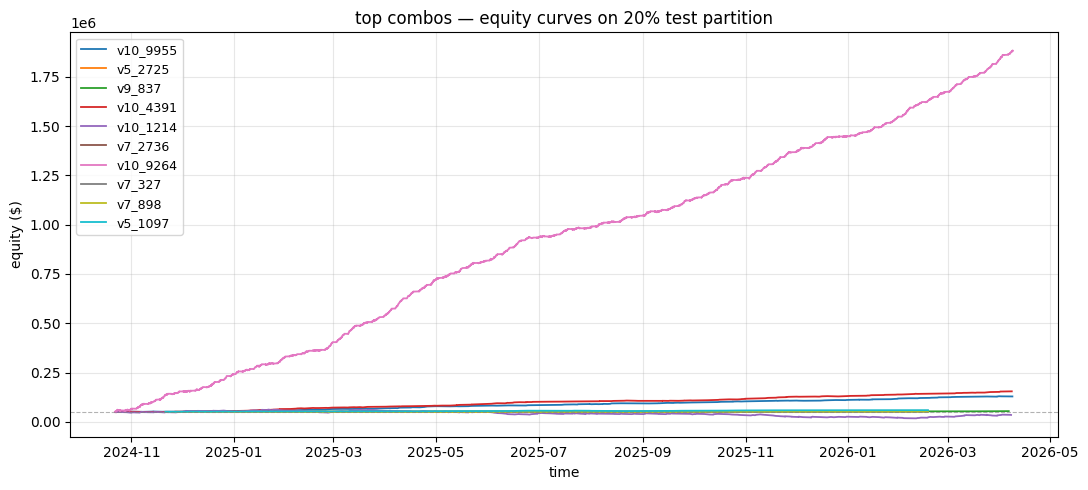

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
for r in results:
    eq = r['equity_curve']
    if len(eq) == 0:
        continue
    ax.plot(eq['time'], eq['equity'], label=r['combo_id'], linewidth=1.3)
ax.axhline(STARTING_EQUITY, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_title('top combos — equity curves on 20% test partition')
ax.set_xlabel('time'); ax.set_ylabel('equity ($)')
ax.legend(loc='best', fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Drawdowns

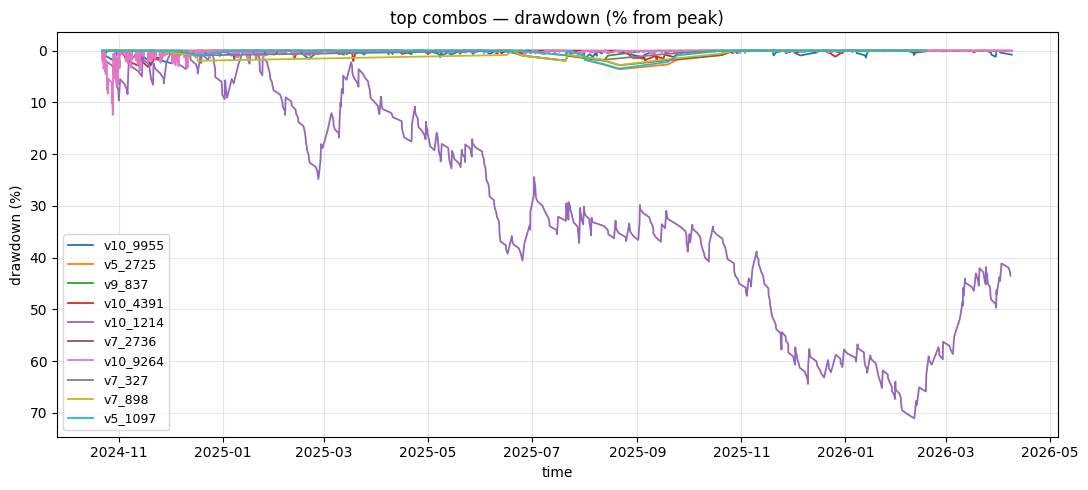

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
start_time = bars['time'].iloc[0]
for r in results:
    eq = r['equity_curve']
    if len(eq) == 0:
        continue
    eq_full = np.concatenate([[STARTING_EQUITY], eq['equity'].to_numpy()])
    peak = np.maximum.accumulate(eq_full)
    dd_pct = (peak - eq_full) / peak * 100
    times = pd.concat([pd.Series([start_time]), pd.Series(eq['time'].values)]).reset_index(drop=True)
    ax.plot(times, dd_pct, label=r['combo_id'], linewidth=1.3)
ax.set_title('top combos — drawdown (% from peak)')
ax.set_xlabel('time'); ax.set_ylabel('drawdown (%)')
ax.invert_yaxis()
ax.legend(loc='best', fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()